In [1]:
cd tumbling_git/

/share/nas2/pryder/tumbling_git


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, EarthSatellite, wgs84
from pc_utils import open_vdif, iq_conversion, range_finder_general, rect

In [3]:
tle_line_1 = '1 61995U 16053M   25035.62796428  .00000095  00000-0  00000-0 0  9998'
tle_line_2 = '2 61995   0.2642  88.1708 0053675 268.4745   3.2920  1.01033442  1106'
target_name = 'intelsat'
ts = load.timescale()
intelsat_tle = EarthSatellite(tle_line_1, tle_line_2, target_name, ts)

In [4]:
# input parameters       
bw = 8e6        
Tp = 800e-6    
pri = 19.7e-3
freq = 1295e6
c = 299792458
samp_rate = 16e6
alpha = bw/Tp   
height = 128 # CPI Size
points = int(samp_rate * pri)

In [6]:
# Open VDIF
pola, header = open_vdif('/share/nas2/pryder/SET_Observations_Test_1/Wednesday/vdifs/TSSat_20250205_lo1_1295MHz_intelsat33e.vdif', 0)
print('VDIF opened.')

# Convert to IQ
iq_samples = iq_conversion(pola)
print('Converted into IQ samples.')

VDIF opened.
Converted into IQ samples.


Total strips to process: 65


FileNotFoundError: [Errno 2] No such file or directory: './plots/incoherent_sum_strip_1.png'

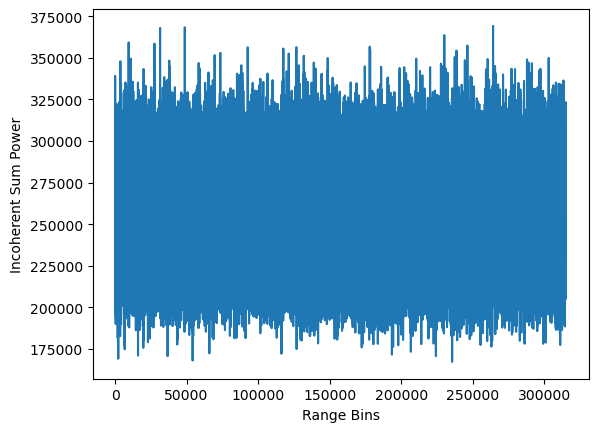

In [48]:
ts = load.timescale()
freqs = np.fft.fftfreq(points, d=1/samp_rate) # Used for Fourier Shift RCM correction
startoffset = int(samp_rate * 100)
overlap_factor = 'min'

if overlap_factor == 'max':
    cpi_jump_samples = 1
    number_of_strips = 200
    overlap_factor = 1

elif overlap_factor == 'min':
    cpi_jump_samples = height * points
    number_of_strips = int((len(iq_samples) - startoffset - (height * points)) // cpi_jump_samples)

else:
    cpi_jump_samples = (height * points) // overlap_factor
    number_of_strips = int((len(iq_samples) - startoffset - (height * points)) // cpi_jump_samples)

rcm_map = np.zeros((points, number_of_strips))

peak_history = []

print(f'Total strips to process: {number_of_strips}')


for n in range(number_of_strips):
    print(f"Processing strip {n+1} of {number_of_strips}", end='\r')
    
    start_idx = startoffset + (n * cpi_jump_samples)
    end_idx = start_idx + (height * points)
    cpi_data = iq_samples[start_idx:end_idx].reshape((height, points))
    
    # Update TLE range rate for the start of this CPI
    s_offset = (start_idx / samp_rate)
    t_tle = ts.utc(2025, 2, 5, 13, 45, s_offset)
    range_rate = range_finder_general(intelsat_tle, t_tle, 'lovell')[1]
    tau_dot = range_rate / c
    
    # Create template: baseband * chirp * envelope
    t_pulse = np.linspace(0, pri, points, endpoint=False)
    template = np.exp(1j * np.pi * alpha * t_pulse**2 * (1 - tau_dot)**2) * rect(t_pulse / (Tp * (1 + tau_dot)))
    template_fft = np.fft.fft(template)

    cdat_pc = np.zeros((height, points), dtype=complex)
    
    # Pulse Compression
    for i in range(height):
        start_sec = i * pri
        pulse_fft = np.fft.fft(cpi_data[i])
        
        # Calculating RCM Correction
        delta_tau = 2 * (range_rate * start_sec) / c     # change in range rate since beginning of CPI, converted to time delay
        rcm_shift = np.exp(1j * 2 * np.pi * freqs * delta_tau)          #applying RCM correction in the frequency domain using linear phase shift corresponding to the change in range delay over the CPI duration
        
        # Pulse Compression and RCM shift
        compressed_pulse = np.fft.ifft(pulse_fft * np.conj(template_fft) * rcm_shift)
        
        # Doppler Phase Correction
        f_d = -2 * range_rate * freq / c
        bulk_phase = np.exp(-1j * 2 * np.pi * f_d * start_sec)
        
        # applying doppler correction
        cdat_pc[i] = compressed_pulse * bulk_phase

    power = np.abs(cdat_pc)**2
    incoho_sum = np.sum(power, axis=0)
    plt.plot(incoho_sum)
    plt.xlabel('Range Bins')
    plt.ylabel('Incoherent Sum Power')
    plt.savefig(f'./plots/incoherent_sum_strip_{n+1}.png')
    plt.show()

    plt.imshow(power[:, 127000:129000], aspect='auto',vmin=0, vmax=5000, cmap='plasma', extent=[127000, 129000, 0, height*pri])
    plt.colorbar(label='Power')
    plt.xlabel('Range Bins')
    plt.ylabel('Time (s)')
    plt.savefig(f'./plots/rti_{n+1}.png')
    plt.show()

    unshifted_range_doppler = np.fft.fft(cdat_pc, axis=0)
    range_doppler = np.fft.fftshift(unshifted_range_doppler, axes=0)

    max_velocity = c / (4 * pri * (freq))

    lowest_value = -max_velocity

    number_of_points = range_doppler.shape[0]
    velocity_axis = np.linspace(lowest_value, max_velocity, number_of_points)
    range_axis = np.linspace(0, pri * c / 2, cdat_pc.shape[1])
    plt.figure()
    plt.pcolormesh(range_axis, velocity_axis, np.abs(range_doppler ** 2), shading="auto", vmax=2e7)
    plt.colorbar()
    plt.xlabel("Range (m)")
    plt.ylabel("Velocity (m/s)")
    plt.title('Intelsat 33e Debris from observations on 5/2/25 with Lovell (lo1)')
    plt.xlim([range_axis[127000], range_axis[129000]])
    plt.savefig(f'./plots/range_doppler_{n+1}.png')
    plt.show()

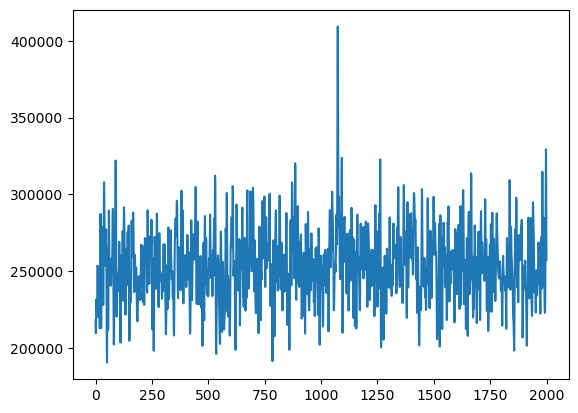

In [39]:
plt.plot(incoho_sum[127000:129000])
plt.show()

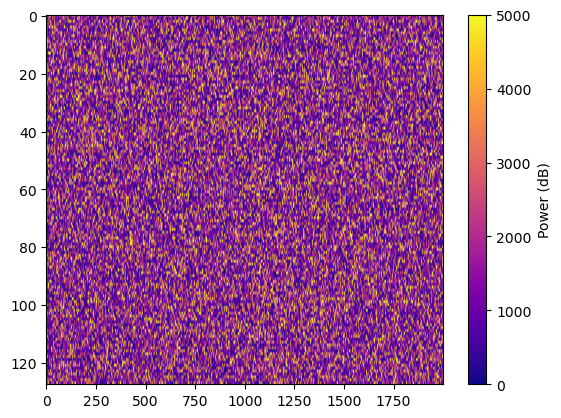

In [47]:
plt.imshow(power[:, 127000:129000], aspect='auto',vmin=0, vmax=5000, cmap='plasma')
plt.colorbar(label='Power (dB)')
plt.show()